Our data is in assignments\Assignment4\transformer_data.csv

It is "time","Y","Ta","S","I" 

It means 

• Yt: The transformer station temperature (◦C).

• Ta,t: The outdoor air temperature (◦C).

• Φs,t: The horizontal global solar radiation (W/m2) --> variable S in dataset

• ΦI,t: The load on the transformer station (kA). --> variable I in dataset


In this exercise, we shall develop models to predict the temperature evolution in transformer station
in a DSO (distribution system operator, distributing electricity from high-voltage grid out to the end
consumer) grid. Transformer stations are vital to the electricity transportation system, and having
the operate optimally is advantagous.
A brief introduction to a transformer station. Roughly speaking, a transformer station receives electricity at a high voltage and sends out electricity at a lower voltage. In this process, some energy is
lost in the transformer and converted into heat. DSO transformer stations typically use oil for cooling
(like water cooling, just with oil). The highest temperature inside the transformer station needs to be
below a given threshold in order to limit the speed of degradation of the transformer station and to
avoid it catching fire. In this data, a good approximation to this temperature is measured. We would
now like a model that is able to predict this temperature.


This is useful because we will be able to predict dangerous temperatures before they happen, and
because we will be able to relate the input (electricity load) to the output (temperature).

We want to relate the impact of I on Y

# 2.1

Load the provided dataset.

• Plot all four variables (Yt, Ta,t, Φs,t, ΦI,t) together in a single figure, using different colors
or panels.

• Use appropriate labels and time axes for clarity.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
fp = "C:\\Users\\leahi\\Documents\\DTU\\Time Series Analysis\\assignments\\Assignment4\\transformer_data.csv"
df = pd.read_csv(fp)

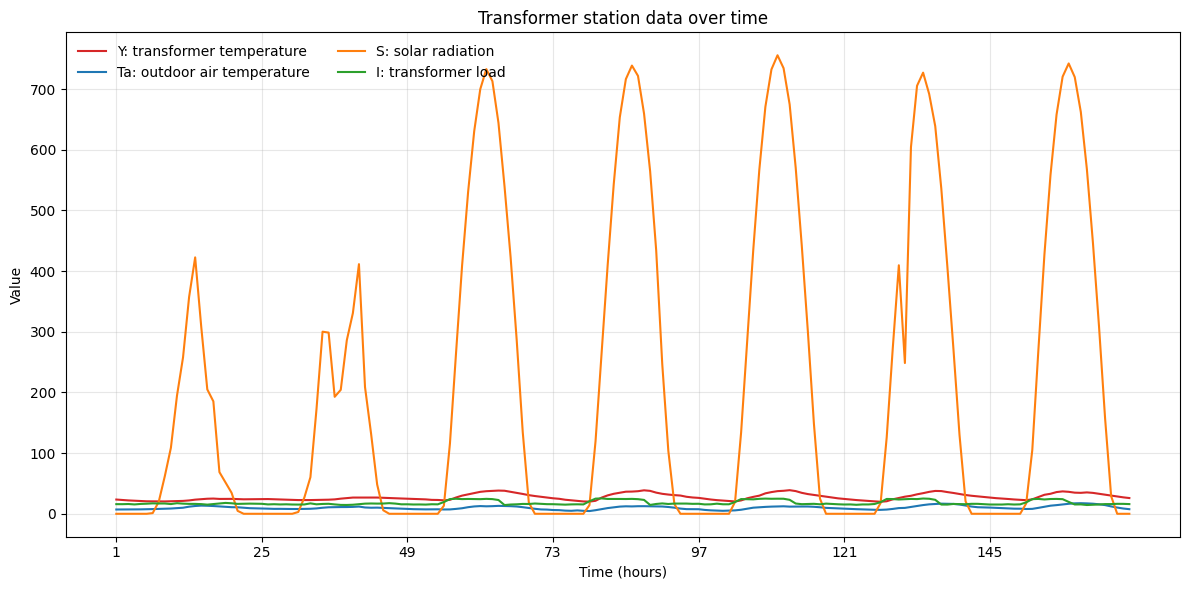

In [5]:
# Use the numeric hour `time` as x-axis
x = df["time"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, df["Y"], color="tab:red", label="Y: transformer temperature")
ax.plot(x, df["Ta"], color="tab:blue", label="Ta: outdoor air temperature")
ax.plot(x, df["S"], color="tab:orange", label="S: solar radiation")
ax.plot(x, df["I"], color="tab:green", label="I: transformer load")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Value")
ax.set_title("Transformer station data over time")
ax.grid(alpha=0.3)
ax.legend(ncol=2, frameon=False)

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    ax.set_xticks(xt)
except Exception:
    pass

plt.tight_layout()
plt.show()

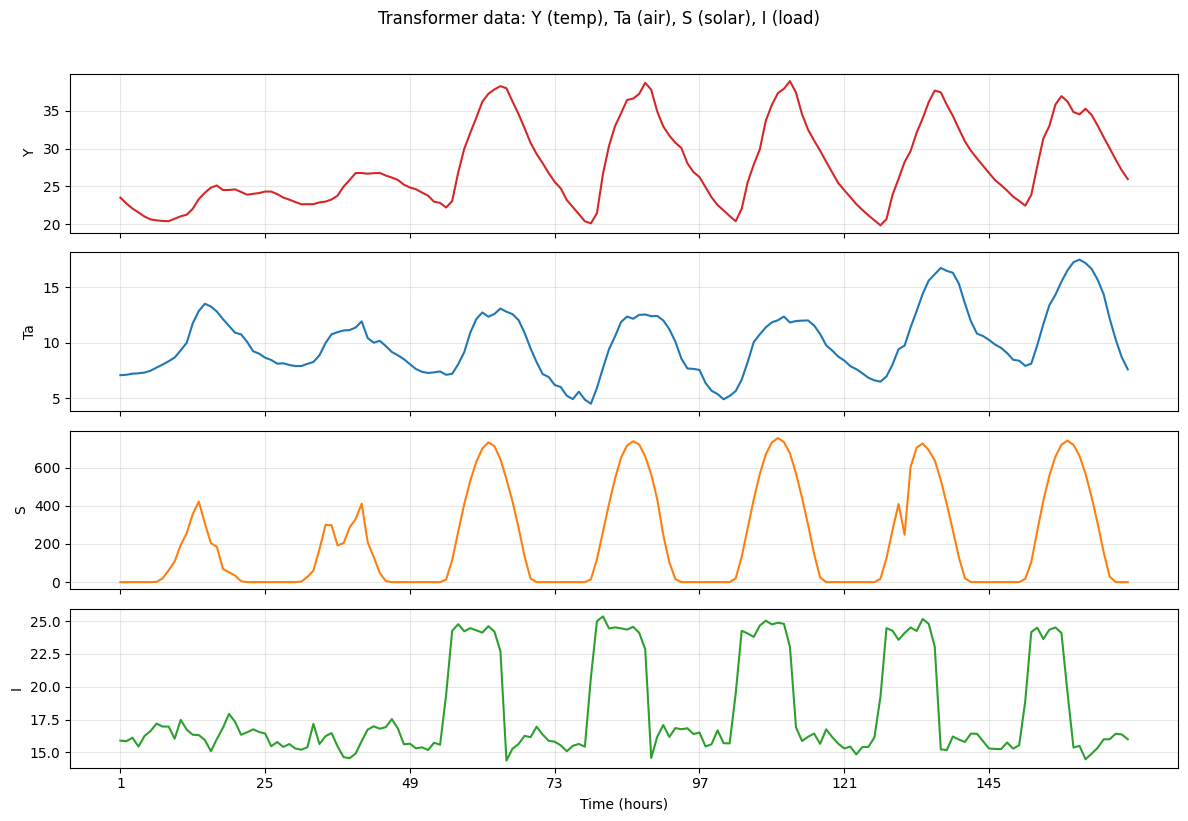

In [7]:


# Use the numeric hour `time` as x-axis
x = df["time"]

# Plot in 4 stacked panels (shared x-axis)
cols = ["Y", "Ta", "S", "I"]
colors = ["tab:red", "tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 8))
for ax, col, c in zip(axes, cols, colors):
    ax.plot(x, df[col], color=c)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (hours)")
fig.suptitle("Transformer data: Y (temp), Ta (air), S (solar), I (load)", y=1.02)
plt.tight_layout()

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    axes[-1].set_xticks(xt)
except Exception:
    pass

plt.show()

# 2.2 



In [ ]:
import numpy as np
from scipy.optimize import minimize


# R-style implementation of the likelihood and optimizer wrapper.
# Parameter vector: [A, B_Ta, B_S, B_I, log_sigma_x, log_sigma_y]
def kf_logLik_dt(par, df):
    A = np.array([[par[0]]], dtype=float)
    B = np.array([[par[1], par[2], par[3]]], dtype=float)
    Qlt = np.array([[np.exp(par[4])]], dtype=float)
    Q = Qlt @ Qlt.T
    H = np.array([[1.0]], dtype=float)
    X0 = np.array([[df["Y"].iloc[0]]], dtype=float)
    R_obs = np.array([[np.exp(2.0 * par[5])]], dtype=float)

    obs_cols = ["Y"]
    input_cols = ["Ta", "S", "I"]

    Y = df[obs_cols].to_numpy(dtype=float)
    U = df[input_cols].to_numpy(dtype=float)
    Tn = len(df)

    n = A.shape[0]
    x_est = X0
    P_est = np.diag(np.full(n, 1e1))
    logLik = 0.0

    for t in range(Tn):
        # prediction step
        u_t = U[t].reshape(-1, 1)
        x_pred = A @ x_est + B @ u_t
        P_pred = A @ P_est @ A.T + Q

        # innovation step
        y_t = Y[t].reshape(-1, 1)
        y_pred = H @ x_pred
        S_t = H @ P_pred @ H.T + R_obs
        innov = y_t - y_pred

        # log-likelihood contribution
        logLik = logLik - 0.5 * (
            np.log(np.linalg.det(2.0 * np.pi * S_t))
            + (innov.T @ np.linalg.solve(S_t, innov))
        )

        # update step
        K_t = P_pred @ H.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
        x_est = x_pred + K_t @ innov
        P_est = (np.eye(n) - K_t @ H) @ P_pred

    return float(np.asarray(logLik).squeeze())


# Backward-compatible alias used elsewhere in the notebook.
kalman_loglik_dt = kf_logLik_dt


# Optimizer wrapper
# Mirrors the R function estimate_dt(start_par, df, lower=NULL, upper=NULL).
def estimate_dt(start_par, df, lower=None, upper=None):
    negLL = lambda par: -kf_logLik_dt(par, df)

    if lower is None:
        lower = np.array([0.0, -2.0, -2.0, -2.0, -8.0, -8.0], dtype=float)
    if upper is None:
        upper = np.array([1.5, 2.0, 2.0, 2.0, 3.0, 3.0], dtype=float)

    return minimize(
        fun=negLL,
        x0=np.asarray(start_par, dtype=float),
        method="L-BFGS-B",
        bounds=list(zip(lower, upper)),
        options={"maxiter": 1000, "disp": True},
    )


# Fit the model
start_par = np.array([
    0.95,
    0.05,
    0.02,
    0.05,
    np.log(0.5),
    np.log(1.0),
], dtype=float)

fit_dt = estimate_dt(start_par, df)
A_hat = np.array([[fit_dt.x[0]]], dtype=float)
B_hat = np.array([[fit_dt.x[1], fit_dt.x[2], fit_dt.x[3]]], dtype=float)
G_hat = np.array([[np.exp(fit_dt.x[4])]], dtype=float)
C_hat = np.array([[1.0]], dtype=float)
Sigma_x_hat = G_hat @ G_hat.T
Sigma_y_hat = np.array([[np.exp(2.0 * fit_dt.x[5])]], dtype=float)

print("Optimization success:", fit_dt.success)
print("Message:", fit_dt.message)
print("Log-likelihood:", kf_logLik_dt(fit_dt.x, df))
print("\nEstimated matrices:")
print("A =", A_hat)
print("B =", B_hat)
print("G =", G_hat)
print("C =", C_hat)
print("Sigma_x =", Sigma_x_hat)
print("Sigma_y =", Sigma_y_hat)

C:\Users\leahi\AppData\Local\Temp\ipykernel_36552\3281347868.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log-likelihood: -165.5069222066195

Estimated matrices:
A = [[0.80097626]]
B = [[0.10202315 0.00287432 0.21342699]]
G = [[0.64437525]]
C = [[1.]]
Sigma_x = [[0.41521946]]
Sigma_y = [[1.12535175e-07]]


Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log-likelihood: -165.5069222066195

Estimated matrices:
A = [[0.80097626]]
B = [[0.10202315 0.00287432 0.21342699]]
G = [[0.64437525]]
C = [[1.]]
Sigma_x = [[0.41521946]]
Sigma_y = [[1.12535175e-07]]